In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Load all data and compute metrics
# ─────────────────────────────────────────────────────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML
import os

# Load data
with open('results/inference_outputs_v3.json') as f:
    results = json.load(f)
with open('results/preprocessed.json') as f:
    preprocessed = json.load(f)

n = len(results)
print(f"Loaded {n} samples")

# ── Compute semantic shifts ───────────────────────────────────────────────────
print("Computing semantic shifts...")
sem_model = SentenceTransformer('all-MiniLM-L6-v2')

shift_data = {step: [] for step in ['perception', 'prediction', 'planning', 'reasoning']}

for r in results:
    for step in shift_data:
        t_non  = r['non_posthoc'].get(step, '')
        t_post = r['posthoc'].get(step, '')
        if t_non and t_post:
            embs = sem_model.encode([t_non, t_post], normalize_embeddings=True)
            shift_data[step].append(1.0 - float(np.dot(embs[0], embs[1])))

# ── Compute decision metrics ──────────────────────────────────────────────────
acc_non    = sum(1 for r in results if r['non_posthoc']['action'] == r['gt_label']) / n
acc_post   = sum(1 for r in results if r['posthoc']['action']    == r['gt_label']) / n
change_rate = sum(1 for r in results
    if r['non_posthoc']['action'] != r['posthoc']['action']) / n
chance_baseline = 1 / len(set(r['gt_label'] for r in results))

print(f"\nDecision metrics:")
print(f"  Non post-hoc accuracy : {acc_non:.3f}")
print(f"  Post-hoc accuracy     : {acc_post:.3f}")
print(f"  Change rate           : {change_rate:.3f}")
print(f"  Chance baseline       : {chance_baseline:.3f}")
print(f"\nSemantic shifts:")
for step, vals in shift_data.items():
    print(f"  {step:<12} mean={np.mean(vals):.4f} std={np.std(vals):.4f}")

Loaded 24 samples
Computing semantic shifts...

Decision metrics:
  Non post-hoc accuracy : 0.417
  Post-hoc accuracy     : 0.417
  Change rate           : 0.458
  Chance baseline       : 0.100

Semantic shifts:
  perception   mean=0.2443 std=0.1273
  prediction   mean=0.2070 std=0.0985
  planning     mean=0.1882 std=0.0669
  reasoning    mean=0.2099 std=0.0743


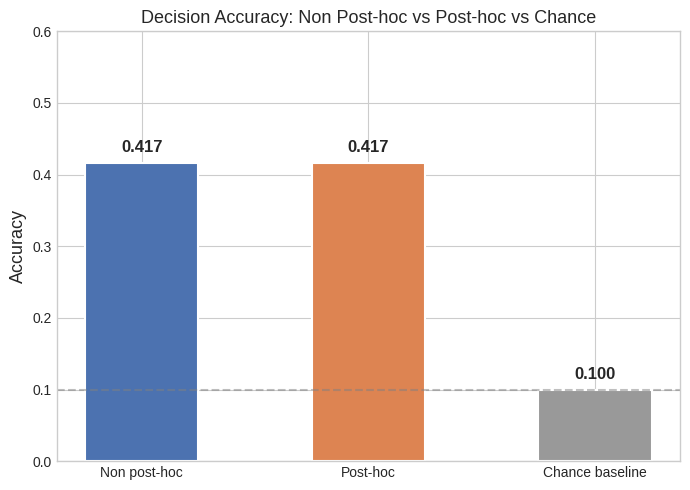

Saved fig1_accuracy_comparison.png


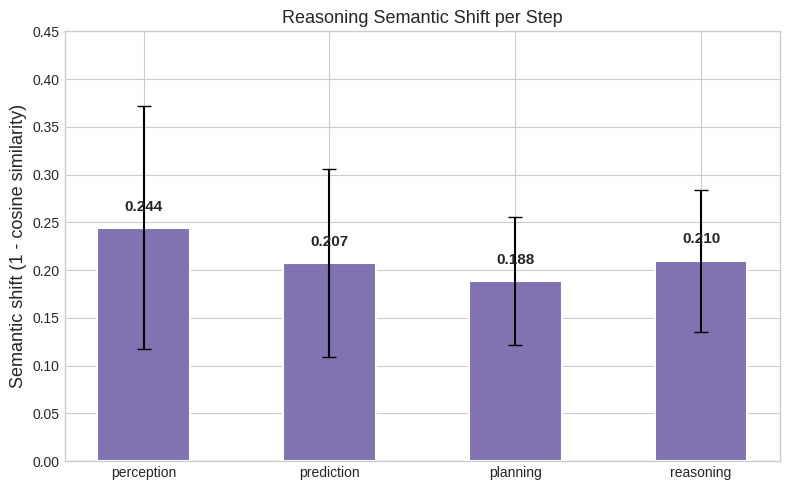

Saved fig2_semantic_shift_per_step.png


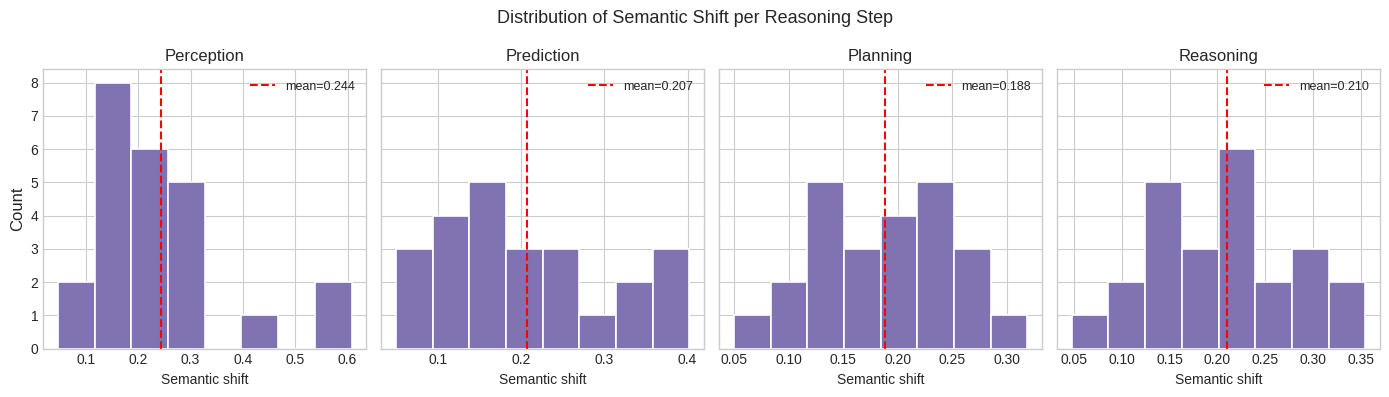

Saved fig3_shift_distribution.png


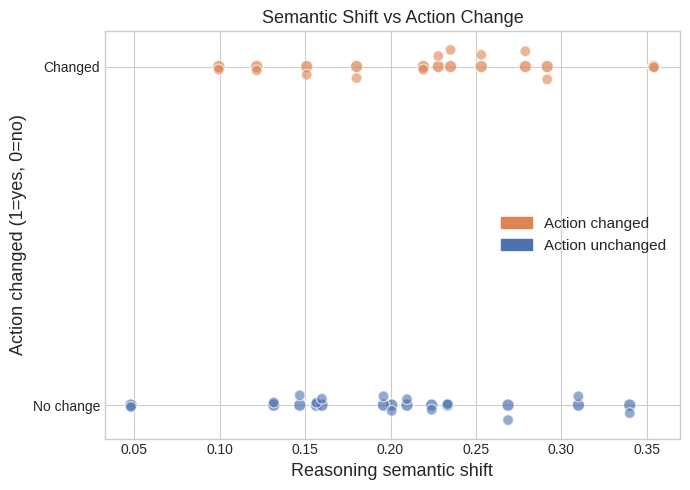

Saved fig4_shift_vs_action_change.png


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Generate all 4 figures
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs('analysis/figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'non': '#4C72B0', 'post': '#DD8452', 'gt': '#55A868', 'neutral': '#8172B2'}

# ── Figure 1: Decision accuracy comparison ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Non post-hoc', 'Post-hoc', 'Chance baseline'],
    [acc_non, acc_post, chance_baseline],
    color=[COLORS['non'], COLORS['post'], '#999999'],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, [acc_non, acc_post, chance_baseline]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Decision Accuracy: Non Post-hoc vs Post-hoc vs Chance', fontsize=13)
ax.set_ylim(0, 0.6)
ax.axhline(y=chance_baseline, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('analysis/figures/fig1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig1_accuracy_comparison.png")

# ── Figure 2: Semantic shift per step ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
steps = ['perception', 'prediction', 'planning', 'reasoning']
means = [np.mean(shift_data[s]) for s in steps]
stds  = [np.std(shift_data[s]) for s in steps]
bars = ax.bar(steps, means, yerr=stds, capsize=5,
              color=COLORS['neutral'], width=0.5,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Semantic shift (1 - cosine similarity)', fontsize=13)
ax.set_title('Reasoning Semantic Shift per Step', fontsize=13)
ax.set_ylim(0, 0.45)
plt.tight_layout()
plt.savefig('analysis/figures/fig2_semantic_shift_per_step.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig2_semantic_shift_per_step.png")

# ── Figure 3: Semantic shift distribution (histogram) ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, step in zip(axes, steps):
    vals = shift_data[step]
    ax.hist(vals, bins=8, color=COLORS['neutral'],
            edgecolor='white', linewidth=1.2)
    ax.axvline(np.mean(vals), color='red', linestyle='--',
               linewidth=1.5, label=f'mean={np.mean(vals):.3f}')
    ax.set_title(step.capitalize(), fontsize=12)
    ax.set_xlabel('Semantic shift', fontsize=10)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Count', fontsize=12)
fig.suptitle('Distribution of Semantic Shift per Reasoning Step', fontsize=13)
plt.tight_layout()
plt.savefig('analysis/figures/fig3_shift_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig3_shift_distribution.png")

# ── Figure 4: Action changed vs semantic shift scatter ────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
reasoning_shifts = shift_data['reasoning']
changed = [1 if r['non_posthoc']['action'] != r['posthoc']['action'] else 0
           for r in results]
colors_scatter = [COLORS['post'] if c else COLORS['non'] for c in changed]
ax.scatter(reasoning_shifts, changed, c=colors_scatter, alpha=0.7, s=80, edgecolor='white')

# Add jitter to y axis for visibility
jitter = np.random.uniform(-0.05, 0.05, len(changed))
ax.scatter(reasoning_shifts, np.array(changed) + jitter,
           c=colors_scatter, alpha=0.6, s=60, edgecolor='white')

changed_patch   = mpatches.Patch(color=COLORS['post'], label='Action changed')
unchanged_patch = mpatches.Patch(color=COLORS['non'],  label='Action unchanged')
ax.legend(handles=[changed_patch, unchanged_patch], fontsize=11)
ax.set_xlabel('Reasoning semantic shift', fontsize=13)
ax.set_ylabel('Action changed (1=yes, 0=no)', fontsize=13)
ax.set_title('Semantic Shift vs Action Change', fontsize=13)
ax.set_yticks([0, 1])
ax.set_yticklabels(['No change', 'Changed'])
plt.tight_layout()
plt.savefig('analysis/figures/fig4_shift_vs_action_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig4_shift_vs_action_change.png")